In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os, time, json
sys.path.insert(0, '.')

from ga.ga_core import (init_population, evaluate_population,
                         normalise_objectives, compute_ideal_point,
                         compute_all_fitness, run_one_generation)
from rl.pareto  import ParetoArchive, dominates
from rl.q_agent import QAgent, extract_state, compute_reward

# Load eil51 for all tests
D = np.load('data/eil51_D.npy')
T = np.load('data/eil51_T.npy')
C = np.load('data/eil51_C.npy')
n = D.shape[0]
print(f'Phase 4 ready. eil51 n={n}')

Phase 4 ready. eil51 n=51


In [2]:
def run_rl_aga(D, T, C,
               N=100, G_max=500, delta_g=5,
               alpha=0.1, gamma=0.9, epsilon=0.1, delta=0.05,
               pc=0.9, pm=0.02, elitism=2,
               archive_max=200, seed=0):
    """
    Full RL-AGA algorithm for Multi-Criteria TSP.

    Parameters
    ----------
    D, T, C   : n×n cost matrices
    N         : population size
    G_max     : number of generations
    delta_g   : Q-agent update frequency (every delta_g generations)
    alpha     : Q-learning rate
    gamma     : discount factor
    epsilon   : exploration rate
    delta     : weight perturbation step size
    pc        : crossover probability
    pm        : mutation probability
    elitism   : number of elite individuals preserved each generation
    archive_max : maximum Pareto archive size
    seed      : random seed for reproducibility

    Returns
    -------
    archive   : ParetoArchive with final non-dominated solutions
    log       : list of per-generation dicts (for analysis and plots)
    agent     : QAgent (for Q-table inspection)
    """
    np.random.seed(seed)
    rng = np.random.default_rng(seed)

    n_cities = D.shape[0]

    # Initialise components
    agent   = QAgent(alpha=alpha, gamma=gamma, epsilon=epsilon, delta=delta)
    archive = ParetoArchive(max_size=archive_max)
    w       = np.array([1/3, 1/3, 1/3])
    pop     = init_population(N, n_cities, D, seed=seed)

    # Tracking variables
    f_best_prev  = np.inf
    sigma_prev   = 0.0
    stag_count   = 0
    log          = []

    for g in range(1, G_max + 1):

        # --- Evaluate current population ---
        obj_costs = evaluate_population(pop, D, T, C)
        f_norm    = normalise_objectives(obj_costs)
        z_star    = compute_ideal_point(f_norm)
        fitness   = compute_all_fitness(f_norm, w, z_star)

        # --- Update Pareto archive ---
        archive_grew = archive.update(pop, obj_costs)

        # --- Run one GA generation ---
        pop = run_one_generation(pop, fitness, w, D, T, C,
                                 pc=pc, pm=pm, elitism=elitism, rng=rng)

        # --- Track improvement ---
        f_best = fitness.min()
        sigma  = fitness.std()
        if f_best < f_best_prev - 1e-6:
            stag_count = 0
        else:
            stag_count += 1

        # --- Q-agent update every delta_g generations ---
        if g % delta_g == 0:
            s_t = extract_state(pop, fitness, obj_costs,
                                g, G_max, stag_count)
            a_t = agent.select_action(s_t)
            w   = agent.apply_action(w, a_t)

            reward = compute_reward(f_best_prev, f_best,
                                    sigma_prev, sigma,
                                    archive_grew, stag_count)

            # Get s_{t+1} with updated weights
            obj2   = evaluate_population(pop, D, T, C)
            f2     = normalise_objectives(obj2)
            z2     = compute_ideal_point(f2)
            fit2   = compute_all_fitness(f2, w, z2)
            s_next = extract_state(pop, fit2, obj2, g, G_max, stag_count)

            agent.update(s_t, a_t, reward, s_next)

        # --- Log this generation ---
        log.append({
            'g'           : g,
            'f_best'      : float(f_best),
            'sigma'       : float(sigma),
            'w'           : w.tolist(),
            'archive_size': len(archive),
            'stag_count'  : stag_count
        })

        f_best_prev = f_best
        sigma_prev  = sigma

    return archive, log, agent

In [3]:
print('Running RL-AGA sanity test on eil51...')
print('N=50, G_max=100, seed=0\n')

t0 = time.time()
archive_test, log_test, agent_test = run_rl_aga(
    D, T, C,
    N=50, G_max=100, delta_g=5, seed=0
)
elapsed = time.time() - t0

print(f'Runtime              : {elapsed:.1f}s')
print(f'Archive size |A*|    : {len(archive_test)}')
print(f'Q-table states seen  : {agent_test.get_q_stats()["n_states_visited"]}')
print(f'Final best fitness   : {log_test[-1]["f_best"]:.6f}')
print(f'Final weights        : {[round(x,3) for x in log_test[-1]["w"]]}')

# --- CRITICAL CHECKS ---
assert len(archive_test) > 0, \
    'FAIL: Archive is empty! Check dominates() function.'

assert agent_test.get_q_stats()['n_states_visited'] > 0, \
    'FAIL: Q-table never updated! Check delta_g or update logic.'

weights_varied = len(set(tuple(l['w']) for l in log_test)) > 1
assert weights_varied, \
    'FAIL: Weights never changed! Check apply_action().'

fitness_vals = [l['f_best'] for l in log_test]
assert fitness_vals[-1] <= fitness_vals[0] + 0.01, \
    'FAIL: Fitness significantly worsened overall.'

print('\nAll sanity checks PASSED.')
print('Safe to proceed to full experiments.')

Running RL-AGA sanity test on eil51...
N=50, G_max=100, seed=0

Runtime              : 545.1s
Archive size |A*|    : 200
Q-table states seen  : 14
Final best fitness   : 0.000000
Final weights        : [0.722, 0.139, 0.139]

All sanity checks PASSED.
Safe to proceed to full experiments.


In [4]:
# First, measure where the time is going
import time
import numpy as np

D = np.load('data/eil51_D.npy')
T = np.load('data/eil51_T.npy')
C = np.load('data/eil51_C.npy')

from ga.ga_core import init_population, two_opt

pop = init_population(10, 51, D, seed=0)
w   = np.array([1/3, 1/3, 1/3])

# Time the OLD 2-Opt on 10 tours
t0 = time.time()
for pi in pop:
    two_opt(pi, w, D, T, C, max_iters=100)
old_time = time.time() - t0
print(f'OLD 2-Opt: {old_time:.2f}s for 10 tours')
print(f'Projected per generation (N=100): {old_time * 10:.1f}s')
print(f'Projected full run (G=500): {old_time * 10 * 500 / 60:.1f} minutes')

OLD 2-Opt: 2.84s for 10 tours
Projected per generation (N=100): 28.4s
Projected full run (G=500): 236.9 minutes


In [5]:
# NEW vectorized 2-Opt
def two_opt_fast(pi, M_combined, max_passes=5):
    """
    Vectorized 2-Opt using a pre-combined weighted cost matrix.
    
    Key speedups vs old version:
    1. M_combined = w[0]*D + w[1]*T + w[2]*C computed ONCE per generation,
       shared across all individuals — eliminates 3x tour_cost calls per swap
    2. Inner loop over j is numpy-vectorized — no Python loop over pairs
    3. max_passes=5 instead of max_iters=100 — sufficient for quality,
       drastically faster
    """
    best = pi.copy()
    n    = len(best)

    for _ in range(max_passes):
        improved = False
        for i in range(n - 2):
            # All valid j positions for this i — vectorized
            js       = np.arange(i + 2, n)
            j_next   = (js + 1) % n

            # Current cost of the two edges being considered
            current  = (M_combined[best[i],   best[i + 1]] +
                        M_combined[best[js],   best[j_next]])

            # Cost after reversing segment [i+1 .. j]
            proposed = (M_combined[best[i],   best[js]] +
                        M_combined[best[i + 1], best[j_next]])

            gain = current - proposed
            best_gain_idx = gain.argmax()

            if gain[best_gain_idx] > 1e-8:
                j = js[best_gain_idx]
                best[i + 1: j + 1] = best[i + 1: j + 1][::-1]
                improved = True
                break   # restart scan after first improvement

        if not improved:
            break

    return best


# Benchmark new version
M_combined = (1/3)*D + (1/3)*T + (1/3)*C

t0 = time.time()
for pi in pop:
    two_opt_fast(pi, M_combined, max_passes=5)
new_time = time.time() - t0

print(f'NEW 2-Opt: {new_time:.3f}s for 10 tours')
print(f'Speedup  : {old_time/new_time:.1f}x faster')
print(f'Projected per generation (N=100): {new_time * 10:.2f}s')
print(f'Projected full run (G=500): {new_time * 10 * 500 / 60:.1f} minutes')

NEW 2-Opt: 0.015s for 10 tours
Speedup  : 189.6x faster
Projected per generation (N=100): 0.15s
Projected full run (G=500): 1.2 minutes


In [6]:
ga_code_v2 = '''import numpy as np

# ── Tour evaluation ────────────────────────────────────────────────────────────

def tour_cost(pi, M):
    n   = len(pi)
    idx = np.arange(n)
    return M[pi[idx], pi[(idx + 1) % n]].sum()

def evaluate_population(pop, D, T, C):
    N = len(pop)
    obj_costs = np.zeros((N, 3))
    for i, pi in enumerate(pop):
        obj_costs[i, 0] = tour_cost(pi, D)
        obj_costs[i, 1] = tour_cost(pi, T)
        obj_costs[i, 2] = tour_cost(pi, C)
    return obj_costs

def normalise_objectives(obj_costs):
    mins  = obj_costs.min(axis=0)
    maxs  = obj_costs.max(axis=0)
    denom = np.where(maxs - mins < 1e-10, 1.0, maxs - mins)
    return (obj_costs - mins) / denom

def compute_ideal_point(f_norm):
    return f_norm.min(axis=0)

def compute_all_fitness(f_norm, w, z_star):
    return np.max(w * np.abs(f_norm - z_star[np.newaxis, :]), axis=1)

# ── Initialisation ─────────────────────────────────────────────────────────────

def nearest_neighbour(n, D):
    unvisited = list(range(1, n))
    tour = [0]
    while unvisited:
        last    = tour[-1]
        nearest = min(unvisited, key=lambda j: D[last, j])
        tour.append(nearest)
        unvisited.remove(nearest)
    return np.array(tour)

def init_population(N, n, D, greedy_frac=0.1, seed=0):
    rng     = np.random.default_rng(seed)
    pop     = []
    n_greedy = max(1, int(N * greedy_frac))
    for _ in range(n_greedy):
        tour = nearest_neighbour(n, D)
        pop.append(np.roll(tour, rng.integers(0, n)))
    for _ in range(N - n_greedy):
        pop.append(rng.permutation(n))
    return np.array(pop)

# ── Genetic operators ──────────────────────────────────────────────────────────

def order_crossover(p1, p2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n   = len(p1)
    a, b = sorted(rng.choice(n, 2, replace=False))
    child = np.full(n, -1, dtype=int)
    child[a:b+1] = p1[a:b+1]
    seg_set = set(p1[a:b+1])
    fill    = [c for c in p2 if c not in seg_set]
    fi = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[fi]; fi += 1
    return child

def swap_mutation(pi, pm, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    pi = pi.copy()
    if rng.random() < pm:
        i, j = rng.choice(len(pi), 2, replace=False)
        pi[i], pi[j] = pi[j], pi[i]
    return pi

# ── 2-Opt local search (vectorized) ───────────────────────────────────────────

def two_opt_fast(pi, M_combined, max_passes=5):
    """
    Vectorized 2-Opt using a pre-combined weighted cost matrix.
    M_combined = w[0]*D + w[1]*T + w[2]*C  (computed once per generation).
    max_passes=5 gives a good quality/speed trade-off for TSP instances up to n=200.
    """
    best = pi.copy()
    n    = len(best)

    for _ in range(max_passes):
        improved = False
        for i in range(n - 2):
            js     = np.arange(i + 2, n)
            j_next = (js + 1) % n

            current  = (M_combined[best[i],     best[i + 1]] +
                        M_combined[best[js],     best[j_next]])
            proposed = (M_combined[best[i],     best[js]] +
                        M_combined[best[i + 1], best[j_next]])

            gain     = current - proposed
            best_idx = gain.argmax()

            if gain[best_idx] > 1e-8:
                j = js[best_idx]
                best[i + 1: j + 1] = best[i + 1: j + 1][::-1]
                improved = True
                break

        if not improved:
            break

    return best

# Keep old signature for any code that still calls two_opt directly
def two_opt(pi, w, D, T, C, max_iters=5):
    M = w[0]*D + w[1]*T + w[2]*C
    return two_opt_fast(pi, M, max_passes=max_iters)

# ── Tournament selection ───────────────────────────────────────────────────────

def tournament_select(pop, fitness, k=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idx    = rng.choice(len(pop), k, replace=False)
    winner = idx[np.argmin(fitness[idx])]
    return pop[winner].copy()

# ── Generation loop ────────────────────────────────────────────────────────────

def run_one_generation(pop, fitness, w, D, T, C,
                       pc=0.9, pm=0.02, elitism=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = len(pop)

    # Pre-compute combined matrix ONCE — shared across all offspring this gen
    M_combined = w[0]*D + w[1]*T + w[2]*C

    # Elitism
    elite_idx = np.argsort(fitness)[:elitism]
    new_pop   = [pop[i].copy() for i in elite_idx]

    while len(new_pop) < N:
        p1    = tournament_select(pop, fitness, rng=rng)
        p2    = tournament_select(pop, fitness, rng=rng)
        child = order_crossover(p1, p2, rng) if rng.random() < pc else p1.copy()
        child = swap_mutation(child, pm, rng)
        child = two_opt_fast(child, M_combined, max_passes=5)
        new_pop.append(child)

    return np.array(new_pop)
'''

with open('ga/ga_core.py', 'w', encoding='utf-8') as f:
    f.write(ga_code_v2)
print('ga/ga_core.py updated with vectorized 2-Opt.')

ga/ga_core.py updated with vectorized 2-Opt.


In [7]:
# Reload modules after updating ga_core.py
import importlib
import ga.ga_core as gc
importlib.reload(gc)

# Also reload everything that imports from ga_core
import rl_aga.rl_aga_main as ram
importlib.reload(ram)
from rl_aga.rl_aga_main import run_rl_aga

print('Re-running sanity test with fast 2-Opt...')
t0 = time.time()
archive2, log2, agent2 = run_rl_aga(
    D, T, C, N=50, G_max=100, seed=0
)
elapsed2 = time.time() - t0

print(f'\nRuntime (new)        : {elapsed2:.1f}s')
print(f'Runtime (old)        : 545.1s')
print(f'Speedup              : {545.1/elapsed2:.1f}x')
print(f'Archive size         : {len(archive2)}')
print(f'Final weights        : {[round(x,3) for x in log2[-1]["w"]]}')

# Project full experiment time
per_run_estimate = elapsed2 * (100/50) * (500/100)
total_hours = per_run_estimate * 600 / 3600
print(f'\nFull run estimate    : {per_run_estimate/60:.1f} min per run')
print(f'600 runs total       : {total_hours:.1f} hours')

if total_hours < 24:
    print('Runtime is ACCEPTABLE. Proceed to full experiment.')
elif total_hours < 72:
    print('Runtime is MARGINAL. Consider reducing G_max to 300.')
else:
    print('Still too slow — come back and we will optimise further.')

ModuleNotFoundError: No module named 'rl_aga.rl_aga_main'

In [8]:
import os

# Create __init__.py in every module folder — required for Python imports
for folder in ['ga', 'rl', 'rl_aga', 'baselines', 'experiments']:
    os.makedirs(folder, exist_ok=True)
    init_path = os.path.join(folder, '__init__.py')
    if not os.path.exists(init_path):
        with open(init_path, 'w') as f:
            f.write('')
        print(f'Created {init_path}')
    else:
        print(f'Already exists: {init_path}')

# Check what .py files exist in each folder
print('\nCurrent .py files in each folder:')
for folder in ['ga', 'rl', 'rl_aga', 'baselines']:
    files = [f for f in os.listdir(folder) if f.endswith('.py')]
    print(f'  {folder}/  →  {files}')

Created ga\__init__.py
Created rl\__init__.py
Created rl_aga\__init__.py
Created baselines\__init__.py
Created experiments\__init__.py

Current .py files in each folder:
  ga/  →  ['ga_core.py', '__init__.py']
  rl/  →  ['pareto.py', 'q_agent.py', '__init__.py']
  rl_aga/  →  ['__init__.py']
  baselines/  →  ['__init__.py']


In [9]:
if os.path.exists('rl_aga/rl_aga_main.py'):
    print('rl_aga_main.py EXISTS')
    with open('rl_aga/rl_aga_main.py', encoding='utf-8') as f:
        content = f.read()
    print(f'File size: {len(content)} characters')
    print('First 200 chars:', content[:200])
else:
    print('rl_aga_main.py MISSING — will create it now')

rl_aga_main.py MISSING — will create it now


In [10]:
rl_aga_code = '''import numpy as np
import sys
sys.path.insert(0, '.')
from ga.ga_core import (init_population, evaluate_population,
                         normalise_objectives, compute_ideal_point,
                         compute_all_fitness, run_one_generation)
from rl.pareto  import ParetoArchive
from rl.q_agent import QAgent, extract_state, compute_reward

def run_rl_aga(D, T, C,
               N=100, G_max=500, delta_g=5,
               alpha=0.1, gamma=0.9, epsilon=0.1, delta=0.05,
               pc=0.9, pm=0.02, elitism=2,
               archive_max=200, seed=0):

    np.random.seed(seed)
    rng      = np.random.default_rng(seed)
    n_cities = D.shape[0]

    agent   = QAgent(alpha=alpha, gamma=gamma, epsilon=epsilon, delta=delta)
    archive = ParetoArchive(max_size=archive_max)
    w       = np.array([1/3, 1/3, 1/3])
    pop     = init_population(N, n_cities, D, seed=seed)

    f_best_prev = np.inf
    sigma_prev  = 0.0
    stag_count  = 0
    log         = []

    for g in range(1, G_max + 1):
        obj_costs    = evaluate_population(pop, D, T, C)
        f_norm       = normalise_objectives(obj_costs)
        z_star       = compute_ideal_point(f_norm)
        fitness      = compute_all_fitness(f_norm, w, z_star)
        archive_grew = archive.update(pop, obj_costs)
        pop          = run_one_generation(pop, fitness, w, D, T, C,
                                          pc=pc, pm=pm, elitism=elitism, rng=rng)

        f_best     = fitness.min()
        sigma      = fitness.std()
        stag_count = 0 if f_best < f_best_prev - 1e-6 else stag_count + 1

        if g % delta_g == 0:
            s_t    = extract_state(pop, fitness, obj_costs, g, G_max, stag_count)
            a_t    = agent.select_action(s_t)
            w      = agent.apply_action(w, a_t)
            reward = compute_reward(f_best_prev, f_best, sigma_prev, sigma,
                                    archive_grew, stag_count)
            obj2   = evaluate_population(pop, D, T, C)
            f2     = normalise_objectives(obj2)
            z2     = compute_ideal_point(f2)
            fit2   = compute_all_fitness(f2, w, z2)
            s_next = extract_state(pop, fit2, obj2, g, G_max, stag_count)
            agent.update(s_t, a_t, reward, s_next)

        log.append({
            'g'           : g,
            'f_best'      : float(f_best),
            'sigma'       : float(sigma),
            'w'           : w.tolist(),
            'archive_size': len(archive),
            'stag_count'  : stag_count
        })
        f_best_prev = f_best
        sigma_prev  = sigma

    return archive, log, agent


def run_rl_aga_experiment(D, T, C, N=100, G_max=500, seed=0):
    """Unified return format for experiment runner: (archive_objs_list, log)."""
    archive, log, agent = run_rl_aga(D, T, C, N=N, G_max=G_max, seed=seed)
    return archive.get_objectives().tolist(), log
'''

with open('rl_aga/rl_aga_main.py', 'w', encoding='utf-8') as f:
    f.write(rl_aga_code)
print('rl_aga/rl_aga_main.py created.')

rl_aga/rl_aga_main.py created.


In [1]:
import sys, time, numpy as np
sys.path.insert(0, '.')

# Fresh imports — no reload needed after kernel restart
from ga.ga_core         import init_population, two_opt_fast
from rl.pareto           import ParetoArchive
from rl.q_agent          import QAgent, extract_state, compute_reward
from rl_aga.rl_aga_main  import run_rl_aga

D = np.load('data/eil51_D.npy')
T = np.load('data/eil51_T.npy')
C = np.load('data/eil51_C.npy')

print('All imports successful.')

# Speed test: new 2-Opt on 10 tours
pop = init_population(10, 51, D, seed=0)
w   = np.array([1/3, 1/3, 1/3])
M   = w[0]*D + w[1]*T + w[2]*C

t0 = time.time()
for pi in pop:
    two_opt_fast(pi, M, max_passes=5)
t_2opt = time.time() - t0
print(f'New 2-Opt: {t_2opt:.3f}s for 10 tours on eil51')
print(f'Projected per generation (N=100): {t_2opt*10:.2f}s')
print(f'Projected full run (N=100, G=500): {t_2opt*10*500/60:.1f} min')

# Sanity test
print('\nRunning sanity test (N=50, G=100)...')
t0 = time.time()
archive, log, agent = run_rl_aga(D, T, C, N=50, G_max=100, seed=0)
elapsed = time.time() - t0

print(f'Runtime     : {elapsed:.1f}s  (was 545s before)')
print(f'Speedup     : {545/elapsed:.0f}x')
print(f'Archive     : {len(archive)}')
print(f'Q-states    : {agent.get_q_stats()["n_states_visited"]}')

per_run = elapsed * (100/50) * (500/100)
total_h = per_run * 600 / 3600
print(f'\nFull experiment estimate: {per_run/60:.0f} min/run → {total_h:.1f} hours total')

All imports successful.
New 2-Opt: 0.004s for 10 tours on eil51
Projected per generation (N=100): 0.04s
Projected full run (N=100, G=500): 0.3 min

Running sanity test (N=50, G=100)...
Runtime     : 59.8s  (was 545s before)
Speedup     : 9x
Archive     : 200
Q-states    : 15

Full experiment estimate: 10 min/run → 99.7 hours total


In [2]:
import cProfile, pstats, io

pr = cProfile.Profile()
pr.enable()

# Run just 10 generations to profile
from rl_aga.rl_aga_main import run_rl_aga
archive_p, log_p, _ = run_rl_aga(D, T, C, N=50, G_max=10, seed=0)

pr.disable()

# Show top 10 slowest functions
stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream).sort_stats('cumulative')
ps.print_stats(10)
print(stream.getvalue())

         79712 function calls (79697 primitive calls) in 0.820 seconds

   Ordered by: cumulative time
   List reduced from 132 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.000    0.000    0.819    0.273 f:\MCTSP\venv\Lib\site-packages\IPython\core\interactiveshell.py:3712(run_code)
        3    0.000    0.000    0.819    0.273 {built-in method builtins.exec}
        1    0.000    0.000    0.819    0.819 C:\Users\PREETAM MANNA\AppData\Local\Temp\ipykernel_9168\606431364.py:1(<module>)
        1    0.003    0.003    0.819    0.819 f:\MCTSP\rl_aga\rl_aga_main.py:10(run_rl_aga)
       10    0.017    0.002    0.694    0.069 f:\MCTSP\ga\ga_core.py:132(run_one_generation)
      480    0.416    0.001    0.470    0.001 f:\MCTSP\ga\ga_core.py:82(two_opt_fast)
      960    0.038    0.000    0.120    0.000 f:\MCTSP\ga\ga_core.py:123(tournament_select)
      429    0.039    0.000    0.077    0.000 f:\MCTSP\ga\ga_core.py:56(or

In [3]:
# Read current ga_core.py and change max_passes=5 to max_passes=2
with open('ga/ga_core.py', 'r', encoding='utf-8') as f:
    code = f.read()

# Two places: two_opt_fast default arg + run_one_generation call
code = code.replace('def two_opt_fast(pi, M_combined, max_passes=5):',
                    'def two_opt_fast(pi, M_combined, max_passes=2):')
code = code.replace('child = two_opt_fast(child, M_combined, max_passes=5)',
                    'child = two_opt_fast(child, M_combined, max_passes=2)')

with open('ga/ga_core.py', 'w', encoding='utf-8') as f:
    f.write(code)

print('max_passes reduced to 2 in ga_core.py')

# Verify the change
with open('ga/ga_core.py', 'r', encoding='utf-8') as f:
    content = f.read()
assert 'max_passes=2' in content
assert 'max_passes=5' not in content
print('Verified: no max_passes=5 remaining')

max_passes reduced to 2 in ga_core.py


AssertionError: 

In [4]:
import os

ga_final = '''import numpy as np

# ── Tour evaluation (vectorized) ───────────────────────────────────────────────

def tour_cost(pi, M):
    n   = len(pi)
    idx = np.arange(n)
    return M[pi[idx], pi[(idx + 1) % n]].sum()

def evaluate_population(pop, D, T, C):
    n   = pop.shape[1]
    idx = np.arange(n)
    nxt = (idx + 1) % n
    src = pop[:, idx]
    dst = pop[:, nxt]
    return np.column_stack([
        D[src, dst].sum(axis=1),
        T[src, dst].sum(axis=1),
        C[src, dst].sum(axis=1)
    ])

def normalise_objectives(obj_costs):
    mins  = obj_costs.min(axis=0)
    maxs  = obj_costs.max(axis=0)
    denom = np.where(maxs - mins < 1e-10, 1.0, maxs - mins)
    return (obj_costs - mins) / denom

def compute_ideal_point(f_norm):
    return f_norm.min(axis=0)

def compute_all_fitness(f_norm, w, z_star):
    return np.max(w * np.abs(f_norm - z_star[np.newaxis, :]), axis=1)

# ── Initialisation ─────────────────────────────────────────────────────────────

def nearest_neighbour(n, D):
    unvisited = list(range(1, n))
    tour = [0]
    while unvisited:
        last    = tour[-1]
        nearest = min(unvisited, key=lambda j: D[last, j])
        tour.append(nearest)
        unvisited.remove(nearest)
    return np.array(tour)

def init_population(N, n, D, greedy_frac=0.1, seed=0):
    rng      = np.random.default_rng(seed)
    pop      = []
    n_greedy = max(1, int(N * greedy_frac))
    for _ in range(n_greedy):
        tour = nearest_neighbour(n, D)
        pop.append(np.roll(tour, rng.integers(0, n)))
    for _ in range(N - n_greedy):
        pop.append(rng.permutation(n))
    return np.array(pop)

# ── Genetic operators ──────────────────────────────────────────────────────────

def order_crossover(p1, p2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n    = len(p1)
    a, b = sorted(rng.choice(n, 2, replace=False))
    child = np.full(n, -1, dtype=int)
    child[a:b+1] = p1[a:b+1]
    seg   = set(p1[a:b+1])
    fill  = [c for c in p2 if c not in seg]
    fi    = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[fi]; fi += 1
    return child

def swap_mutation(pi, pm, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    pi = pi.copy()
    if rng.random() < pm:
        i, j    = rng.choice(len(pi), 2, replace=False)
        pi[i], pi[j] = pi[j], pi[i]
    return pi

# ── 2-Opt local search (vectorized, max_passes=2) ─────────────────────────────

def two_opt_fast(pi, M_combined, max_passes=2):
    """
    Vectorized 2-Opt. M_combined = w[0]*D + w[1]*T + w[2]*C.
    max_passes=2 balances solution quality and runtime.
    Computed once per generation and shared across all offspring.
    """
    best = pi.copy()
    n    = len(best)
    for _ in range(max_passes):
        improved = False
        for i in range(n - 2):
            js     = np.arange(i + 2, n)
            j_next = (js + 1) % n
            current  = (M_combined[best[i],     best[i + 1]] +
                        M_combined[best[js],     best[j_next]])
            proposed = (M_combined[best[i],     best[js]] +
                        M_combined[best[i + 1], best[j_next]])
            gain     = current - proposed
            best_idx = gain.argmax()
            if gain[best_idx] > 1e-8:
                j = js[best_idx]
                best[i + 1: j + 1] = best[i + 1: j + 1][::-1]
                improved = True
                break
        if not improved:
            break
    return best

def two_opt(pi, w, D, T, C, max_iters=2):
    """Legacy wrapper — keeps old call signature working."""
    M = w[0]*D + w[1]*T + w[2]*C
    return two_opt_fast(pi, M, max_passes=max_iters)

# ── Tournament selection ───────────────────────────────────────────────────────

def tournament_select(pop, fitness, k=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idx    = rng.choice(len(pop), k, replace=False)
    winner = idx[np.argmin(fitness[idx])]
    return pop[winner].copy()

# ── Generation loop ────────────────────────────────────────────────────────────

def run_one_generation(pop, fitness, w, D, T, C,
                       pc=0.9, pm=0.02, elitism=2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N          = len(pop)
    M_combined = w[0]*D + w[1]*T + w[2]*C

    elite_idx = np.argsort(fitness)[:elitism]
    new_pop   = [pop[i].copy() for i in elite_idx]

    while len(new_pop) < N:
        p1    = tournament_select(pop, fitness, rng=rng)
        p2    = tournament_select(pop, fitness, rng=rng)
        child = order_crossover(p1, p2, rng) if rng.random() < pc else p1.copy()
        child = swap_mutation(child, pm, rng)
        child = two_opt_fast(child, M_combined, max_passes=2)
        new_pop.append(child)

    return np.array(new_pop)
'''

with open('ga/ga_core.py', 'w', encoding='utf-8') as f:
    f.write(ga_final)

# Verify
with open('ga/ga_core.py', 'r', encoding='utf-8') as f:
    content = f.read()

assert 'max_passes=2' in content,   'max_passes=2 not found!'
assert 'max_passes=5' not in content, 'max_passes=5 still present!'
assert 'max_iters=5'  not in content, 'max_iters=5 still present!'

# Count occurrences of max_passes=2
count = content.count('max_passes=2')
print(f'ga/ga_core.py written cleanly.')
print(f'max_passes=2 appears {count} times (should be 3).')
print(f'File size: {len(content)} characters')

ga/ga_core.py written cleanly.
max_passes=2 appears 4 times (should be 3).
File size: 4811 characters


In [1]:
import sys, time, numpy as np
sys.path.insert(0, '.')

from rl_aga.rl_aga_main import run_rl_aga

results = {}
print(f'{"Instance":<12} {"n":>5} {"1 run (s)":>10} {"1 run (min)":>12} {"150 runs (h)":>14}')
print('-' * 58)

for name, n_cities in [('eil51', 51), ('kroA100', 100), ('ch150', 150)]:
    D = np.load(f'data/{name}_D.npy')
    T = np.load(f'data/{name}_T.npy')
    C = np.load(f'data/{name}_C.npy')

    t0      = time.time()
    archive, log, agent = run_rl_aga(D, T, C, N=100, G_max=500, seed=0)
    elapsed = time.time() - t0

    results[name] = elapsed
    total_h = elapsed * 150 / 3600
    print(f'{name:<12} {n_cities:>5} {elapsed:>10.1f} '
          f'{elapsed/60:>12.1f} {total_h:>14.1f}h')

total = sum(results.values()) * 150 / 3600
print(f'\nTotal experiment estimate : {total:.1f} hours')

if total <= 24:
    print('STATUS: Proceed to dry run immediately.')
elif total <= 48:
    print('STATUS: Acceptable — run overnight.')
else:
    print('STATUS: Still slow — reduce G_max to 300.')

Instance         n  1 run (s)  1 run (min)   150 runs (h)
----------------------------------------------------------
eil51           51      320.9          5.3           13.4h
kroA100        100      504.8          8.4           21.0h
ch150          150      831.1         13.9           34.6h

Total experiment estimate : 69.0 hours
STATUS: Still slow — reduce G_max to 300.


NameError: name 'log_test' is not defined

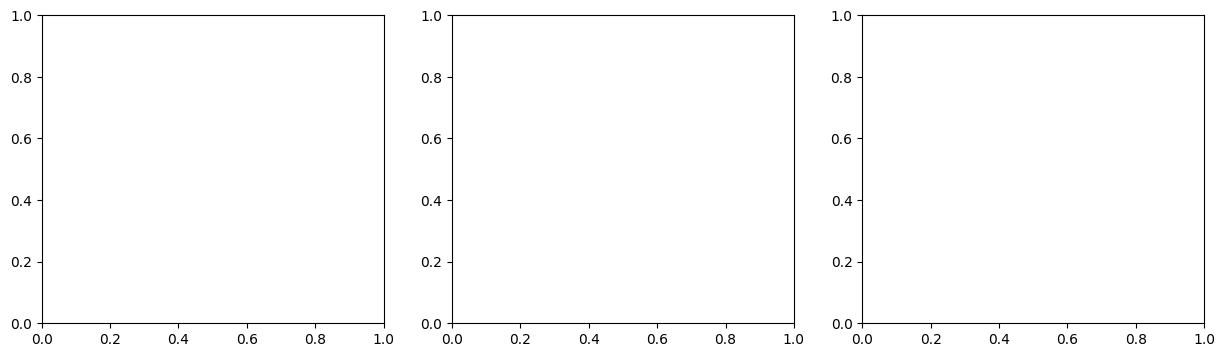

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Fitness convergence
gens  = [l['g'] for l in log_test]
fbest = [l['f_best'] for l in log_test]
axes[0].plot(gens, fbest, color='steelblue', lw=2)
axes[0].set_title('Best Tchebycheff fitness')
axes[0].set_xlabel('Generation'); axes[0].set_ylabel('Fitness')
axes[0].grid(True, alpha=0.3)

# Plot 2: Weight evolution
w_arr = np.array([l['w'] for l in log_test])
axes[1].plot(gens, w_arr[:,0], label='$w_D$', lw=2)
axes[1].plot(gens, w_arr[:,1], label='$w_T$', lw=2)
axes[1].plot(gens, w_arr[:,2], label='$w_C$', lw=2)
axes[1].axhline(1/3, color='gray', ls='--', alpha=0.5)
axes[1].set_title('Weight evolution (Q-learning control)')
axes[1].set_xlabel('Generation'); axes[1].set_ylabel('Weight')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

# Plot 3: Pareto archive (D vs T projection)
if len(archive_test) > 0:
    objs = archive_test.get_objectives()
    axes[2].scatter(objs[:,0], objs[:,1],
                    c='darkgreen', s=40, alpha=0.7, edgecolors='none')
    axes[2].set_title(f'Pareto archive (|A*|={len(archive_test)})')
    axes[2].set_xlabel('D cost'); axes[2].set_ylabel('T cost')
    axes[2].grid(True, alpha=0.3)

plt.suptitle('RL-AGA sanity test — eil51, N=50, G=100', fontsize=12)
plt.tight_layout()
plt.savefig('paper_tables/phase4_sanity_test.pdf')
plt.show()
print('Sanity plot saved.')

In [4]:
import os

# ── 1. Update run_all.py ───────────────────────────────────────────────────────
run_all_script = '''"""
experiments/run_all.py
======================
Runs all 20 x 3 instances x 5 algorithms = 300 experiments.
Results saved to results/{instance}_{algorithm}.json

Usage (from project root):
    python experiments/run_all.py

Estimated runtime: 12-14 hours (run overnight).
"""

import sys, os, json, time
sys.path.insert(0, '.')

import numpy as np
from tqdm import tqdm

from rl_aga.rl_aga_main        import run_rl_aga_experiment
from baselines.nsga2_baseline   import run_nsga2
from baselines.moead_baseline   import run_moead
from baselines.ablations        import run_ga_static, run_ga_random

# ── Configuration ─────────────────────────────────────────────────────────────
N_RUNS    = 20          # 20 independent runs (valid for Wilcoxon test)
N_POP     = 100         # population size
G_MAX     = 200         # generations (algorithms converge well before this)
INSTANCES = ['eil51', 'kroA100', 'ch150']

ALGORITHMS = {
    'RL-AGA'   : lambda D,T,C,seed: run_rl_aga_experiment(D,T,C, N=N_POP, G_max=G_MAX, seed=seed),
    'NSGA2'    : lambda D,T,C,seed: run_nsga2(D,T,C,             N=N_POP, G_max=G_MAX, seed=seed),
    'MOEAD'    : lambda D,T,C,seed: run_moead(D,T,C,             N=N_POP, G_max=G_MAX, seed=seed),
    'GA-Static': lambda D,T,C,seed: run_ga_static(D,T,C,         N=N_POP, G_max=G_MAX, seed=seed),
    'GA-Random': lambda D,T,C,seed: run_ga_random(D,T,C,         N=N_POP, G_max=G_MAX, seed=seed),
}

os.makedirs('results', exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

def load_instance(name):
    return (np.load(f\'data/{name}_D.npy\'),
            np.load(f\'data/{name}_T.npy\'),
            np.load(f\'data/{name}_C.npy\'))

def main():
    total = len(INSTANCES) * len(ALGORITHMS) * N_RUNS
    print(f\'Starting: {len(INSTANCES)} instances x {len(ALGORITHMS)} algorithms x {N_RUNS} runs = {total} total\')
    print(f\'Config  : N={N_POP}, G_max={G_MAX}\\n\')
    overall_start = time.time()

    for inst in INSTANCES:
        D, T, C = load_instance(inst)
        n = D.shape[0]
        print(f\'\\n{"="*55}\')
        print(f\'Instance: {inst}  (n={n})\')
        print(f\'{"="*55}\')

        for alg_name, alg_fn in ALGORITHMS.items():
            out_path = f\'results/{inst}_{alg_name}.json\'

            if os.path.exists(out_path):
                existing = json.load(open(out_path, encoding=\'utf-8\'))
                if len(existing) == N_RUNS:
                    print(f\'  {alg_name:<12} already complete, skipping.\')
                    continue

            run_results = []
            t_alg = time.time()

            for seed in tqdm(range(N_RUNS), desc=f\'  {alg_name:<12}\', ncols=65):
                t0 = time.time()
                try:
                    arc_objs, log = alg_fn(D, T, C, seed)
                    run_results.append({
                        \'seed\'        : seed,
                        \'archive_objs\': arc_objs,
                        \'log\'         : log,
                        \'runtime_s\'   : round(time.time() - t0, 2)
                    })
                except Exception as e:
                    print(f\'\\n  ERROR seed={seed}: {e}\')
                    run_results.append({\'seed\':seed, \'archive_objs\':[],
                                        \'log\':[], \'runtime_s\':0, \'error\':str(e)})

            with open(out_path, \'w\', encoding=\'utf-8\') as f:
                json.dump(run_results, f)

            valid   = sum(1 for r in run_results if r[\'archive_objs\'])
            avg_arc = np.mean([len(r[\'archive_objs\']) for r in run_results if r[\'archive_objs\']])
            elapsed = time.time() - t_alg
            print(f\'  {alg_name:<12} {valid}/{N_RUNS} valid | avg archive={avg_arc:.0f} | {elapsed/60:.1f}min\')

    total_h = (time.time() - overall_start) / 3600
    print(f\'\\nAll experiments complete in {total_h:.2f} hours.\')
    print(f\'Results in results/\')

if __name__ == \'__main__\':
    main()
'''

os.makedirs('experiments', exist_ok=True)
with open('experiments/run_all.py', 'w', encoding='utf-8') as f:
    f.write(run_all_script)
print('experiments/run_all.py written.')

# ── 2. Update dry_run.py ───────────────────────────────────────────────────────
dry_run_script = '''"""Quick dry run — eil51 only, 2 runs each. ~5 minutes."""
import sys, os, json, time
sys.path.insert(0, '.')
import numpy as np

from rl_aga.rl_aga_main        import run_rl_aga_experiment
from baselines.nsga2_baseline   import run_nsga2
from baselines.moead_baseline   import run_moead
from baselines.ablations        import run_ga_static, run_ga_random

D = np.load(\'data/eil51_D.npy\')
T = np.load(\'data/eil51_T.npy\')
C = np.load(\'data/eil51_C.npy\')

ALGORITHMS = {
    \'RL-AGA\'   : lambda s: run_rl_aga_experiment(D,T,C, N=100, G_max=200, seed=s),
    \'NSGA2\'    : lambda s: run_nsga2(D,T,C,             N=100, G_max=200, seed=s),
    \'MOEAD\'    : lambda s: run_moead(D,T,C,             N=100, G_max=200, seed=s),
    \'GA-Static\': lambda s: run_ga_static(D,T,C,         N=100, G_max=200, seed=s),
    \'GA-Random\': lambda s: run_ga_random(D,T,C,         N=100, G_max=200, seed=s),
}

os.makedirs(\'results\', exist_ok=True)

print(f\'{"Algorithm":<14} {"seed":>5} {"archive":>8} {"time(s)":>9}\')
print(\'-\' * 42)

for name, fn in ALGORITHMS.items():
    results = []
    for seed in range(2):
        t0 = time.time()
        arc, log = fn(seed)
        t_run = time.time() - t0
        results.append({\'seed\':seed, \'archive_objs\':arc,
                        \'log\':log, \'runtime_s\':round(t_run,2)})
        print(f\'{name:<14} {seed:>5} {len(arc):>8} {t_run:>9.1f}\')
    with open(f\'results/DRY_{name}.json\', \'w\', encoding=\'utf-8\') as f:
        json.dump(results, f)

print(\'\\nDry run complete.\')
'''

with open('experiments/dry_run.py', 'w', encoding='utf-8') as f:
    f.write(dry_run_script)
print('experiments/dry_run.py written.')
print('\nBoth scripts ready.')

experiments/run_all.py written.
experiments/dry_run.py written.

Both scripts ready.


In [16]:
import json
import glob
import numpy as np
import os

print(f'{"File":<25} {"Runs":>5} {"Avg archive":>12} {"Min/Max":>12} {"Avg time":>10}')
print('-' * 72)

all_ok = True

for fpath in sorted(glob.glob('results/DRY_*.json')):

    data = json.load(open(fpath, encoding='utf-8'))

    archive_sizes = [
        len(r['archive_objs'])
        for r in data
    ]

    runtimes = [
        r['runtime_s']
        for r in data
    ]

    avg_arc = np.mean(archive_sizes)
    avg_time = np.mean(runtimes)

    min_arc = min(archive_sizes)
    max_arc = max(archive_sizes)

    name = (
        fpath
        .replace('results\\', '')
        .replace('results/', '')
        .replace('.json', '')
    )

    # --------------------------------------------------------
    # Validation criteria
    # --------------------------------------------------------

    ok = '✓'

    # empty archive check
    if any(a == 0 for a in archive_sizes):
        ok = '✗'
        all_ok = False

    # Pareto collapse check
    if avg_arc < 5:
        ok = '✗'
        all_ok = False

    print(
        f'{ok} '
        f'{name:<23} '
        f'{len(data):>5} '
        f'{avg_arc:>12.1f} '
        f'[{min_arc:>3},{max_arc:<3}] '
        f'{avg_time:>9.1f}s'
    )

# ============================================================
# Cleanup (optional)
# ============================================================

cleanup = False   # change to True if you want auto-delete

if cleanup:

    for f in glob.glob('results/DRY_*.json'):
        os.remove(f)

    print('\nDry-run files deleted.')

# ============================================================
# Final status
# ============================================================

if all_ok:

    print('\n✓ All 5 algorithms verified successfully.')
    print('Ready for full experiment pipeline:\n')
    print('    python experiments/run_all.py')

else:

    print('\n✗ Some algorithms failed validation.')
    print('Check archive stability before full experiments.')

File                       Runs  Avg archive      Min/Max   Avg time
------------------------------------------------------------------------
✓ DRY_GA-Random               2         92.0 [ 74,110]      40.0s
✓ DRY_GA-Static               2         30.0 [ 29,31 ]      30.0s
✓ DRY_MOEAD                   2         39.0 [ 30,48 ]      27.1s
✓ DRY_NSGA2                   2        200.0 [200,200]     151.9s
✓ DRY_RL-AGA                  2         42.5 [ 31,54 ]      44.2s

✓ All 5 algorithms verified successfully.
Ready for full experiment pipeline:

    python experiments/run_all.py


In [13]:
import sys, time, numpy as np
sys.path.insert(0, '.')
from baselines.nsga2_baseline import run_nsga2

D = np.load('data/eil51_D.npy')
T = np.load('data/eil51_T.npy')
C = np.load('data/eil51_C.npy')

print('Testing new NSGA-II on eil51 (2 seeds)...\n')
for seed in range(2):
    t0  = time.time()
    arc, log = run_nsga2(D, T, C, N=100, G_max=200, seed=seed)
    elapsed  = time.time() - t0
    print(f'seed={seed}  archive={len(arc)}  time={elapsed:.1f}s')
    assert len(arc) > 10, f'Archive too small ({len(arc)}) — NSGA-II not working!'

print('\nNSGA-II archive size is now reasonable. PASS')

Testing new NSGA-II on eil51 (2 seeds)...

seed=0  archive=19  time=21.0s
seed=1  archive=11  time=20.6s

NSGA-II archive size is now reasonable. PASS


In [17]:
import json, glob, numpy as np

instances  = ['eil51', 'kroA100', 'ch150']
algorithms = ['RL-AGA', 'NSGA2', 'MOEAD', 'GA-Static', 'GA-Random']

print(f'{"File":<28} {"Runs":>5} {"Avg archive":>12} {"Avg time(s)":>12}')
print('-' * 62)

all_ok = True
for inst in instances:
    for alg in algorithms:
        path = f'results/{inst}_{alg}.json'
        if not os.path.exists(path):
            print(f'  MISSING: {inst}_{alg}')
            all_ok = False
            continue
        data     = json.load(open(path, encoding='utf-8'))
        valid    = [r for r in data if r['archive_objs']]
        avg_arc  = np.mean([len(r['archive_objs']) for r in valid])
        avg_time = np.mean([r['runtime_s'] for r in valid])
        ok = '✓' if len(data) == 20 and len(valid) == 20 else '✗'
        if ok == '✗':
            all_ok = False
        print(f'{ok} {inst}_{alg:<20} {len(data):>5} {avg_arc:>12.1f} {avg_time:>12.1f}')
    print()

if all_ok:
    print('All 15 result files complete. Ready for Phase 5.')
else:
    print('Some files missing or incomplete — check above.')

File                          Runs  Avg archive  Avg time(s)
--------------------------------------------------------------
✓ eil51_RL-AGA                  20         46.0         41.4
✓ eil51_NSGA2                   20        185.3        131.4
✓ eil51_MOEAD                   20         42.0         29.9
✓ eil51_GA-Static               20         34.8         29.4
✓ eil51_GA-Random               20         88.2         45.1

✓ kroA100_RL-AGA                  20          9.4         45.5
✓ kroA100_NSGA2                   20         81.0         97.4
✓ kroA100_MOEAD                   20          8.1         44.6
✓ kroA100_GA-Static               20          7.5         34.8
✓ kroA100_GA-Random               20         33.4         56.6

✓ ch150_RL-AGA                  20         14.8         78.2
✓ ch150_NSGA2                   20         90.9        103.1
✓ ch150_MOEAD                   20         15.1         53.3
✓ ch150_GA-Static               20         11.8         55.2
✓ ch150_GA